# Lab 5: Linear Regression — Predicting House Prices

**Name:** Haseeb Hassan

**Student ID:** 023-24-0274

**Section:** H

**GitHub Profile:** [Haseeb-Hassan66](https://github.com/Haseeb-Hassan66)

**Kaggle Profile:** [haseebsamo66737](https://www.kaggle.com/haseebsamo66737)

**Dataset:** House Prices - Advanced Regression Techniques (train.csv, test.csv)

**Dataset Source:** [House Prices - Advanced Regression Techniques — Kaggle](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

---

## Part 1 — Dataset, Problem & Feature/Target Identification

### 1. Problem Definition · 2. Dataset Exploration · 3. Feature and Target Identification

**Tasks 1–3**

1. Load the dataset and briefly inspect it (shape, dtypes, first few rows, summary statistics).
2. Identify the dependent variable and list the independent variables, split explicitly into numerical features and categorical features.
3. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

Task 1:

In [53]:
# Task 1 — load the dataset and inspect it
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [55]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Task 1:**

The dataset has 1460 rows and 81 columns - that's 79 features plus Id and SalePrice. Each row is one house sold in Ames, Iowa. info() shows most columns are int64/float64 (numerical, like LotArea, GrLivArea, YearBuilt) and the rest are object type, which are the categorical ones like Neighborhood, HouseStyle, KitchenQual. describe() shows SalePrice goes from about $34,900 to $755,000, averaging around $180,921. A few columns like LotFrontage, MasVnrArea and GarageYrBlt have fewer than 1460 non-null values, so there are missing values I'll need to handle later.

**Task 2:**

The target is SalePrice, and it's a continuous number.

The other 79 columns are the independent variables. Numerical ones include things like LotArea, OverallQual, OverallCond, YearBuilt, YearRemodAdd, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, GrLivArea, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars, GarageArea, WoodDeckSF, OpenPorchSF, MoSold, YrSold, etc.

Categorical ones include MSZoning, Street, LotShape, Neighborhood, Condition1, BldgType, HouseStyle, RoofStyle, Exterior1st, ExterQual, Foundation, BsmtQual, HeatingQC, CentralAir, KitchenQual, GarageType, SaleType, SaleCondition, etc. A lot of these are quality ratings like Ex/Gd/TA/Fa/Po.

Id is just a row number so it's not used as a feature. For this lab I only picked 12 of these 79 features (8 numerical, 4 categorical) instead of using all of them.

**Task 3:**

This is a regression problem because SalePrice is a continuous dollar value, not a category. Since the output is a number and not a class, I can't check the model with accuracy or precision/recall - I need to use regression metrics like MAE, MSE, RMSE and R2 instead.

---

## Part 2 — Data Preparation & Train/Test Split

### 4. Data Preparation

**Tasks 4–6**

4. Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form, and briefly justify your choice of encoding method for each type of column.
5. Confirm X is fully numeric with no missing values.
6. Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

**Task 4:**

79 raw features is too many to fully work with in this lab, so I picked 12 (8 numerical + 4 categorical) that I'd expect to matter most for price: overall quality, living area, basement size, garage capacity, year built, bathrooms, first floor area, neighborhood, house style, and quality ratings.

In [56]:
# Task 4 — select a subset of features expected to matter for price
features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'FullBath',
    'GarageArea',
    '1stFlrSF',
    'Neighborhood',
    'HouseStyle',
    'KitchenQual',
    'ExterQual'
]

X = df[features]
y = df['SalePrice']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (1460, 12)
Target (y): (1460,)


In [57]:
X.head()

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,GarageArea,1stFlrSF,Neighborhood,HouseStyle,KitchenQual,ExterQual
0,7,1710,856,2,2003,2,548,856,CollgCr,2Story,Gd,Gd
1,6,1262,1262,2,1976,2,460,1262,Veenker,1Story,TA,TA
2,7,1786,920,2,2001,2,608,920,CollgCr,2Story,Gd,Gd
3,7,1717,756,3,1915,1,642,961,Crawfor,2Story,Gd,TA
4,8,2198,1145,3,2000,2,836,1145,NoRidge,2Story,Gd,Gd


In [58]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   TotalBsmtSF   1460 non-null   int64
 3   GarageCars    1460 non-null   int64
 4   YearBuilt     1460 non-null   int64
 5   FullBath      1460 non-null   int64
 6   GarageArea    1460 non-null   int64
 7   1stFlrSF      1460 non-null   int64
 8   Neighborhood  1460 non-null   str  
 9   HouseStyle    1460 non-null   str  
 10  KitchenQual   1460 non-null   str  
 11  ExterQual     1460 non-null   str  
dtypes: int64(8), str(4)
memory usage: 137.0 KB


In [59]:
# Encode the categorical columns using one-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual'],
    dtype=int
)

print("Encoded shape:", X_encoded.shape)
X_encoded.head()

Encoded shape: (1460, 49)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,GarageArea,1stFlrSF,Neighborhood_Blmngtn,Neighborhood_Blueste,...,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA
0,7,1710,856,2,2003,2,548,856,0,0,...,0,0,0,0,1,0,0,0,1,0
1,6,1262,1262,2,1976,2,460,1262,0,0,...,0,0,0,0,0,1,0,0,0,1
2,7,1786,920,2,2001,2,608,920,0,0,...,0,0,0,0,1,0,0,0,1,0
3,7,1717,756,3,1915,1,642,961,0,0,...,0,0,0,0,1,0,0,0,0,1
4,8,2198,1145,3,2000,2,836,1145,0,0,...,0,0,0,0,1,0,0,0,1,0


In [61]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   OverallQual           1460 non-null   int64
 1   GrLivArea             1460 non-null   int64
 2   TotalBsmtSF           1460 non-null   int64
 3   GarageCars            1460 non-null   int64
 4   YearBuilt             1460 non-null   int64
 5   FullBath              1460 non-null   int64
 6   GarageArea            1460 non-null   int64
 7   1stFlrSF              1460 non-null   int64
 8   Neighborhood_Blmngtn  1460 non-null   int64
 9   Neighborhood_Blueste  1460 non-null   int64
 10  Neighborhood_BrDale   1460 non-null   int64
 11  Neighborhood_BrkSide  1460 non-null   int64
 12  Neighborhood_ClearCr  1460 non-null   int64
 13  Neighborhood_CollgCr  1460 non-null   int64
 14  Neighborhood_Crawfor  1460 non-null   int64
 15  Neighborhood_Edwards  1460 non-null   int64
 16  Neighborhood_Gilb

**Task 4 (encoding):**

The numerical features (OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt, FullBath, GarageArea, 1stFlrSF) are already numbers so I left them as they are, LinearRegression can use them directly.

The categorical features (Neighborhood, HouseStyle, KitchenQual, ExterQual) I one-hot encoded with get_dummies. I didn't just turn them into plain integers (1, 2, 3...) because that would make the model assume a real numeric order between categories, which isn't true for something like Neighborhood. Even for KitchenQual and ExterQual where there's kind of an order, using plain integers forces the price effect between quality levels to be exactly linear, and there's no reason to assume that. One-hot encoding lets the model learn its own separate coefficient for each category instead.

After encoding, X went from 12 columns to 49, since every category becomes its own column.

**Task 5:**

In [62]:
# Task 5 — confirm X is fully numeric with no missing values
X_encoded.isnull().sum()[X_encoded.isnull().sum() > 0]

Series([], dtype: int64)

In [63]:
print("Total missing values in X_encoded:", X_encoded.isnull().sum().sum())
print("Non-numeric columns remaining:", X_encoded.select_dtypes(exclude='number').shape[1])

Total missing values in X_encoded: 0
Non-numeric columns remaining: 0


**Task 5:**

X_encoded has 0 missing values and 0 non-numeric columns left. All 49 columns are numeric now, so it's ready to go into LinearRegression.

**Task 6:**

In [64]:
# Task 6 — 80/20 train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set :", X_test.shape, y_test.shape)

Training set: (1168, 49) (1168,)
Testing set : (292, 49) (292,)


**Task 6:**

I split the data 80/20 with random_state=42 so it's reproducible. Training set has 1168 houses, test set has 292, both with the same 49 columns. The model only trains on the training set and gets evaluated on the test set, which it never sees during training.

---

## Part 3 — Linear Regression & Predictions

### 6. Linear Regression Model · 7. Predictions

**Tasks 7–8**

7. Train a LinearRegression model on the training data.
8. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

**Task 7:**

In [66]:
from sklearn.linear_model import LinearRegression

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully on", X_train.shape[0], "houses and", X_train.shape[1], "features.")

Linear Regression model trained successfully on 1168 houses and 49 features.


**Task 8:**

In [67]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 292


In [68]:
comparison = pd.DataFrame({
    'Actual SalePrice': y_test.values,
    'Predicted SalePrice': y_pred
})
comparison['Difference'] = comparison['Actual SalePrice'] - comparison['Predicted SalePrice']

comparison.head(10).round(2)

,Actual SalePrice,Predicted SalePrice,Difference
0,154500,138061.94,16438.06
1,325000,322748.33,2251.67
2,115000,113992.61,1007.39
3,159000,174611.24,-15611.24
4,315500,305693.90,9806.10
5,75500,67683.61,7816.39
6,311500,233372.18,78127.82
7,146000,144665.71,1334.29
8,84500,67272.32,17227.68
9,135500,117450.67,18049.33


**Task 8:**

The table compares actual vs predicted price for the first 10 test houses. Some predictions are pretty close, off by a few thousand dollars, but a couple are off by a lot more. That makes sense since I'm only using 12 out of the 79 available features. I'll check the actual accuracy properly with MAE/MSE/RMSE/R2 in Part 5.

---

## Part 4 — Coefficients & Intercept

### 8. Coefficients and Intercept

**Tasks 9–10**

9. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
10. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

**Task 9:**

In [69]:
# Extract the intercept
intercept = model.intercept_
print("Intercept (b0):", round(intercept, 2))

Intercept (b0): -400897.57


In [70]:
# Build the raw coefficient table
coefficient_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
coefficient_table

,Feature,Coefficient
0,OverallQual,12456.439447
1,GrLivArea,70.085205
2,TotalBsmtSF,10.734439
3,GarageCars,10232.880946
4,YearBuilt,205.645277
5,FullBath,-502.019508
6,GarageArea,5.251397
7,1stFlrSF,-24.332059
8,Neighborhood_Blmngtn,-22589.058411
9,Neighborhood_Blueste,-24220.059806


In [71]:
# Add a plain-English interpretation for each feature
categorical_prefixes = ['Neighborhood_', 'HouseStyle_', 'KitchenQual_', 'ExterQual_']

def interpret_coefficient(row):
    feature = row['Feature']
    coef = row['Coefficient']
    amount = abs(coef)
    direction = "increase" if coef > 0 else "decrease"

    is_categorical = any(feature.startswith(p) for p in categorical_prefixes)

    if is_categorical:
        cat_name, cat_value = feature.split('_', 1)
        return (f"Compared to the baseline category, a house with {cat_name} = '{cat_value}' is "
                f"associated with an approximately ${amount:,.0f} {direction} in predicted SalePrice, "
                f"holding all other features constant.")
    else:
        return (f"Each one-unit increase in {feature} is associated with an approximately "
                f"${amount:,.2f} {direction} in predicted SalePrice, holding other features constant.")

coefficient_table['Interpretation'] = coefficient_table.apply(interpret_coefficient, axis=1)
pd.set_option('display.max_colwidth', None)
coefficient_table

,Feature,Coefficient,Interpretation
0,OverallQual,12456.439447,"Each one-unit increase in OverallQual is associated with an approximately $12,456.44 increase in predicted SalePrice, holding other features constant."
1,GrLivArea,70.085205,"Each one-unit increase in GrLivArea is associated with an approximately $70.09 increase in predicted SalePrice, holding other features constant."
2,TotalBsmtSF,10.734439,"Each one-unit increase in TotalBsmtSF is associated with an approximately $10.73 increase in predicted SalePrice, holding other features constant."
3,GarageCars,10232.880946,"Each one-unit increase in GarageCars is associated with an approximately $10,232.88 increase in predicted SalePrice, holding other features constant."
4,YearBuilt,205.645277,"Each one-unit increase in YearBuilt is associated with an approximately $205.65 increase in predicted SalePrice, holding other features constant."
5,FullBath,-502.019508,"Each one-unit increase in FullBath is associated with an approximately $502.02 decrease in predicted SalePrice, holding other features constant."
6,GarageArea,5.251397,"Each one-unit increase in GarageArea is associated with an approximately $5.25 increase in predicted SalePrice, holding other features constant."
7,1stFlrSF,-24.332059,"Each one-unit increase in 1stFlrSF is associated with an approximately $24.33 decrease in predicted SalePrice, holding other features constant."
8,Neighborhood_Blmngtn,-22589.058411,"Compared to the baseline category, a house with Neighborhood = 'Blmngtn' is associated with an approximately $22,589 decrease in predicted SalePrice, holding all other features constant."
9,Neighborhood_Blueste,-24220.059806,"Compared to the baseline category, a house with Neighborhood = 'Blueste' is associated with an approximately $24,220 decrease in predicted SalePrice, holding all other features constant."


**Task 9:**

The intercept is about -$400,897.57. Looking at the numerical features, OverallQual (+$12,456 per point), GarageCars (+$10,233 per car) and YearBuilt (+$206 per year) have the biggest positive effect per unit. GrLivArea, TotalBsmtSF and GarageArea have much smaller per-unit effects, but that's just because square footage is measured in much bigger numbers to begin with.

For the one-hot neighborhoods, NoRidge (+$53,223), StoneBr (+$40,603) and having an excellent kitchen (+$31,866) add the most value compared to the baseline category, while neighborhoods like BrDale and OldTown have big negative coefficients.

**Task 10:**

No, the intercept doesn't really mean anything real here. It's the predicted price when every single feature is 0 - OverallQual = 0, GrLivArea = 0, YearBuilt = 0, no neighborhood/style/quality dummy active. That's not a real house, since a house can't have 0 living area or be built in year 0, and OverallQual only goes from 1 to 10 anyway. So the intercept is just a math constant needed to make the regression fit, not an actual "base price" for anything real.

---

## Part 5 — Residuals & Regression Metrics

### 9. Residual Analysis · 10. Regression Metrics

**Tasks 11–13**

11. Compute residuals on the test set and plot them (residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?
12. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
13. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

**Task 11:**

In [72]:
# Compute residuals on the test set
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals.head(10).round(2))
print("\nResidual mean:", round(residuals.mean(), 2), " | Residual std:", round(residuals.std(), 2))

First 10 residuals:
892     16438.06
1105     2251.67
413      1007.39
522    -15611.24
1036     9806.10
614      7816.39
218     78127.82
1160     1334.29
649     17227.68
887     18049.33
Name: SalePrice, dtype: float64

Residual mean: 807.07  | Residual std: 34256.13


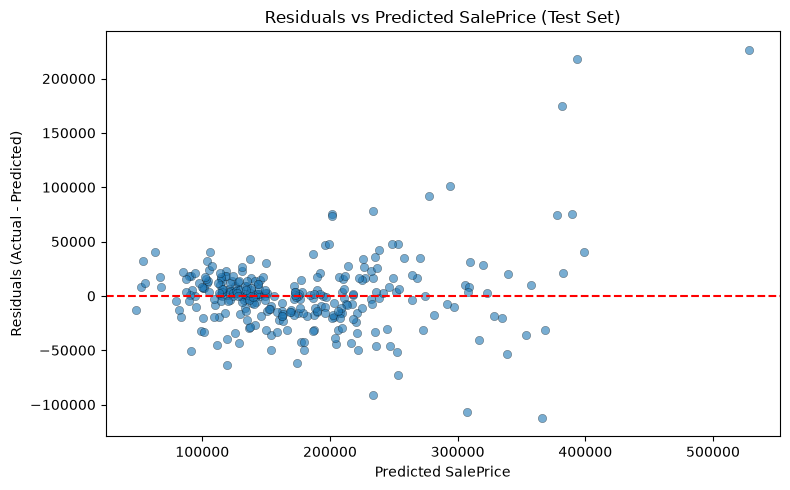

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted SalePrice (Test Set)")
plt.tight_layout()
plt.show()

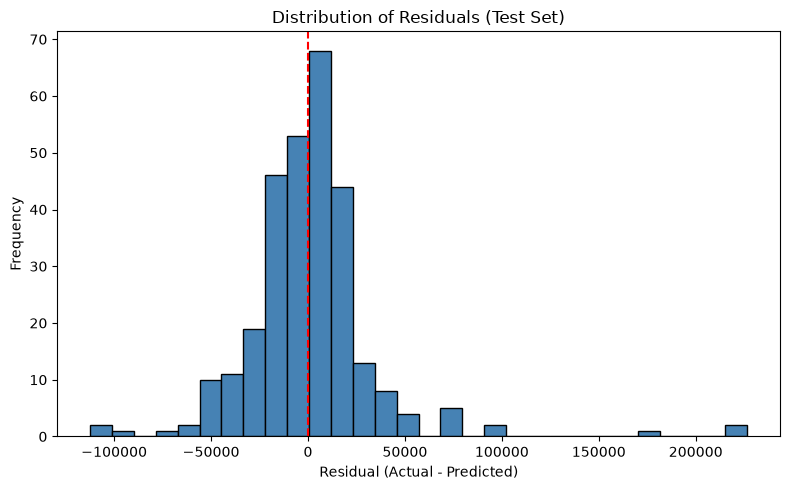

In [74]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Test Set)")
plt.tight_layout()
plt.show()

**Task 11:**

The residuals are centered close to 0 (mean around $807, which is small compared to the ~$181k average price) and look fairly random for low to mid priced houses, which is what a good model should look like. But it's not perfectly random - the spread gets wider as predicted price goes up, kind of a cone shape, and a few expensive houses have big positive residuals meaning the model is under-predicting them. The histogram is roughly bell-shaped around 0 but has a long tail on the right, from those same expensive houses. So the model does fine for average houses but is less reliable for the really expensive ones.

**Task 12:**

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
})
metrics_table['Value'] = metrics_table['Value'].round(4)
metrics_table

,Metric,Value
0,MAE,2.096464e+04
1,MSE,1.170115e+09
2,RMSE,3.420694e+04
3,R2,8.474000e-01


**Task 12:**

On the test set: MAE is about $20,964.64, MSE is about 1,170,114,929.79, RMSE is about $34,206.94, and R2 is about 0.8474. So on average the model is off by roughly $21k, and it explains about 84.7% of the variance in SalePrice using just 12 features.

**Task 13:**

MAE ($20,964.64) is the average error in actual dollars, so it's easy to read directly - the model is off by about $21k on average.

MSE (about 1.17 billion) squares the errors before averaging, so it punishes bigger mistakes a lot more, but the units are squared dollars which don't mean anything by themselves.

RMSE ($34,206.94) is just the square root of MSE, so it's back in normal dollars but still weighs big errors more than MAE does. RMSE will always be a bit higher than MAE, and the gap between them shows there are some bigger misses in there, matching what the residual plots showed for expensive houses.

R2 (0.8474) tells us how much of the price variation the model explains, on a 0 to 1 scale. It's good for judging the model overall without worrying about dollar units.

If I had to show this to someone non-technical I'd go with MAE. Saying "the model is off by about $21,000 on average" is something anyone gets right away, way easier than explaining squared errors or R2.

---

## Part 6 — Training vs. Testing & Generalization

### 11. Training vs Testing Performance

**Tasks 14–15**

14. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Part 5 test-set metrics in one comparison table.
15. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

**Task 14:**

In [76]:
# Predictions on the training set
y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

train_vs_test = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Training Set': [train_mae, train_mse, train_rmse, train_r2],
    'Test Set': [mae, mse, rmse, r2]
})
train_vs_test[['Training Set', 'Test Set']] = train_vs_test[['Training Set', 'Test Set']].round(4)
train_vs_test

,Metric,Training Set,Test Set
0,MAE,2.036887e+04,2.096464e+04
1,MSE,1.035126e+09,1.170115e+09
2,RMSE,3.217337e+04,3.420694e+04
3,R2,8.265000e-01,8.474000e-01


**Task 14:**

Training performance (MAE ~$20,368.87, RMSE ~$32,173.37, R2 ~0.8265) is basically the same as test performance (MAE ~$20,964.64, RMSE ~$34,206.94, R2 ~0.8474), actually slightly better on the test set here.

**Task 15:**

There's no big gap between train and test, and R2 is actually a bit higher on test than on training. If training performance was way better than test performance, that would point to overfitting - the model memorizing the training houses instead of learning something that generalizes. Since the gap here is small (and even flipped), the model isn't overfitting. Part of that is just because it's a simple model with only 12 features, so there isn't enough complexity to memorize the training data anyway, and this particular 80/20 split happened to land a slightly easier test set.

---

## Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

### 12. Model Interpretation · 13. Conclusion

**Tasks 16–19**

16. Looking back at your Part 4 coefficient table, which 2–3 features appear most influential on price?
17. Write a short final interpretation (5–7 sentences).
18. Apply the same feature selection and encoding to test.csv, predict SalePrice, and build submission.csv.
19. Submit submission.csv on Kaggle and record your leaderboard score/rank.

**Task 16:**

In [77]:
# Task 16 — rank features by absolute coefficient magnitude
coefficient_table['Abs_Coefficient'] = coefficient_table['Coefficient'].abs()
top_features = coefficient_table.sort_values('Abs_Coefficient', ascending=False).head(10)
top_features[['Feature', 'Coefficient', 'Abs_Coefficient']]

,Feature,Coefficient,Abs_Coefficient
23,Neighborhood_NoRidge,53223.326879,53223.326879
30,Neighborhood_StoneBr,40603.039676,40603.039676
32,Neighborhood_Veenker,36010.237392,36010.237392
41,KitchenQual_Ex,31865.515718,31865.515718
24,Neighborhood_NridgHt,31161.388696,31161.388696
12,Neighborhood_ClearCr,28562.639756,28562.639756
10,Neighborhood_BrDale,-24750.793557,24750.793557
9,Neighborhood_Blueste,-24220.059806,24220.059806
8,Neighborhood_Blmngtn,-22589.058411,22589.058411
25,Neighborhood_OldTown,-21486.757568,21486.757568


**Task 16:**

By raw coefficient size, the top features are the premium neighborhood dummies - NoRidge (+$53,223), StoneBr (+$40,603), Veenker (+$36,010) - plus KitchenQual_Ex (+$31,866) and NridgHt (+$31,161).

But raw coefficient size can be misleading. A one-hot column is only ever 0 or 1, so its coefficient is exactly its dollar effect whenever it's active. GrLivArea on the other hand has a small coefficient (about $70 per sq ft) just because square footage is measured in the thousands - over a normal range of about 1000 sq ft that's still around $70,000 of price impact, which is just as big as the neighborhood effects, if not bigger.

So thinking about actual value ranges instead of just raw coefficient size, the features that really move the price the most are OverallQual (big effect per point, ranges 1-10), GrLivArea (small effect per unit but a huge range), and Neighborhood/location.

**Task 17 - Final Interpretation:**

Using only 12 out of the 79 available features, the model explains about 84.7% of the variance in sale price (test R2 around 0.847) and is off by roughly $21,000 on average on a typical sale price of about $181,000. That's a solid result for such a small feature set, and since training and test scores are close, the model isn't overfitting. For a non-technical audience I'd show MAE since it's directly in dollars and easy to understand. OverallQual, GrLivArea and Neighborhood turned out to matter the most once you account for their real value ranges, not just raw coefficient size. The main limitation is that Linear Regression assumes everything is linear and additive, so it can't capture things like a big house mattering even more in an expensive neighborhood, or diminishing returns for really high-end homes, and it's clearly less accurate for the most expensive houses based on the residual plots. With more time I'd try adding features like total square footage or house age, log-transforming SalePrice and the area columns to fix the widening residual spread, and comparing this against Ridge/Lasso or tree-based models like Random Forest to see if they handle the nonlinear parts better.

**Task 18:**

In [78]:
# Task 18 — apply the same feature selection & encoding to test.csv, then predict SalePrice
test_df = pd.read_csv('test.csv')
print("Raw test set shape:", test_df.shape)

X_new = test_df[features].copy()

# Handle the small number of missing values present only in test.csv
# (numerical -> median from the training feature set, categorical -> mode from the training feature set)
numeric_feats = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'GarageArea', '1stFlrSF']
categorical_feats = ['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual']

print("Missing values in test features before imputation:")
print(X_new.isnull().sum()[X_new.isnull().sum() > 0])

for col in numeric_feats:
    if X_new[col].isnull().any():
        X_new[col] = X_new[col].fillna(X[col].median())

for col in categorical_feats:
    if X_new[col].isnull().any():
        X_new[col] = X_new[col].fillna(X[col].mode()[0])

print("\nMissing values in test features after imputation:", X_new.isnull().sum().sum())

Raw test set shape: (1459, 80)
Missing values in test features before imputation:
TotalBsmtSF    1
GarageCars     1
GarageArea     1
KitchenQual    1
dtype: int64

Missing values in test features after imputation: 0


In [79]:
# One-hot encode the same way as the training features, then align columns
X_new_encoded = pd.get_dummies(X_new, columns=categorical_feats, dtype=int)

# Align test columns to the exact training columns (adds any missing dummy columns as 0,
# drops any category only seen in test, and puts columns in the same order as X_train)
X_new_encoded = X_new_encoded.reindex(columns=X_train.columns, fill_value=0)

print("Aligned test feature shape:", X_new_encoded.shape)
assert list(X_new_encoded.columns) == list(X_train.columns), "Column mismatch between train and test features!"
print("Test feature columns match training feature columns exactly:", list(X_new_encoded.columns) == list(X_train.columns))

Aligned test feature shape: (1459, 49)
Test feature columns match training feature columns exactly: True


In [80]:
# Predict SalePrice for every row of test.csv and build the submission file
test_predictions = model.predict(X_new_encoded)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

print("Submission shape:", submission.shape)
submission.head()

Submission shape: (1459, 2)


,Id,SalePrice
0,1461,116091.488379
1,1462,160353.381535
2,1463,161086.125639
3,1464,181968.325666
4,1465,249771.757642


In [81]:
submission.to_csv('submission.csv', index=False)
print("submission.csv saved.")

# Sanity-check the format against sample_submission.csv
sample_sub = pd.read_csv('sample_submission.csv')
print("sample_submission.csv shape:", sample_sub.shape, " | columns:", list(sample_sub.columns))
print("submission.csv shape:        ", submission.shape, " | columns:", list(submission.columns))
print("Row count matches sample submission:", submission.shape[0] == sample_sub.shape[0])

submission.csv saved.
sample_submission.csv shape: (1459, 2)  | columns: ['Id', 'SalePrice']
submission.csv shape:         (1459, 2)  | columns: ['Id', 'SalePrice']
Row count matches sample submission: True


**Task 18:**

I applied the same 12 features and the same one-hot encoding to test.csv. A few features (TotalBsmtSF, GarageCars, GarageArea, KitchenQual) had one missing value each in test.csv, so instead of dropping rows I filled them in using the median (numerical) or mode (categorical) from the training features, since every one of the 1459 test houses needs a prediction. After one-hot encoding I reindexed the test columns to match the 49 training columns exactly (any dummy missing from this data gets filled with 0, anything only present in test gets dropped), so the model sees the same layout it was trained on. The final submission.csv has exactly 2 columns (Id, SalePrice) and 1459 rows, matching sample_submission.csv.

**Task 19 - Kaggle Leaderboard Submission:**

Public leaderboard score: 0.16624

Public leaderboard rank: 2615

Reflection: Seeing 2615 out of thousands was a bit humbling after an 84% test R2 looked so solid, but it's a fair baseline for a 12-feature model and shows exactly where more feature work could help.

---

## Submission Checklist

- [x] Student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Source)
- [x] 1. Problem Definition
- [x] 2. Dataset Exploration
- [x] 3. Feature and Target Identification
- [x] 4. Data Preparation
- [x] 5. Train/Test Split
- [x] 6. Linear Regression Model
- [x] 7. Predictions
- [x] 8. Coefficients and Intercept
- [x] 9. Residual Analysis
- [x] 10. Regression Metrics
- [x] 11. Training vs Testing Performance
- [x] 12. Model Interpretation
- [x] 13. Conclusion
- [x] Every table/plot/metric has a short written interpretation
- [x] `submission.csv` generated with exactly `Id` and `SalePrice` columns, matching `sample_submission.csv`'s row count
- [x] `submission.csv` uploaded to Kaggle and leaderboard score/rank recorded above (Task 19 — must be done on Kaggle's website, outside this notebook)